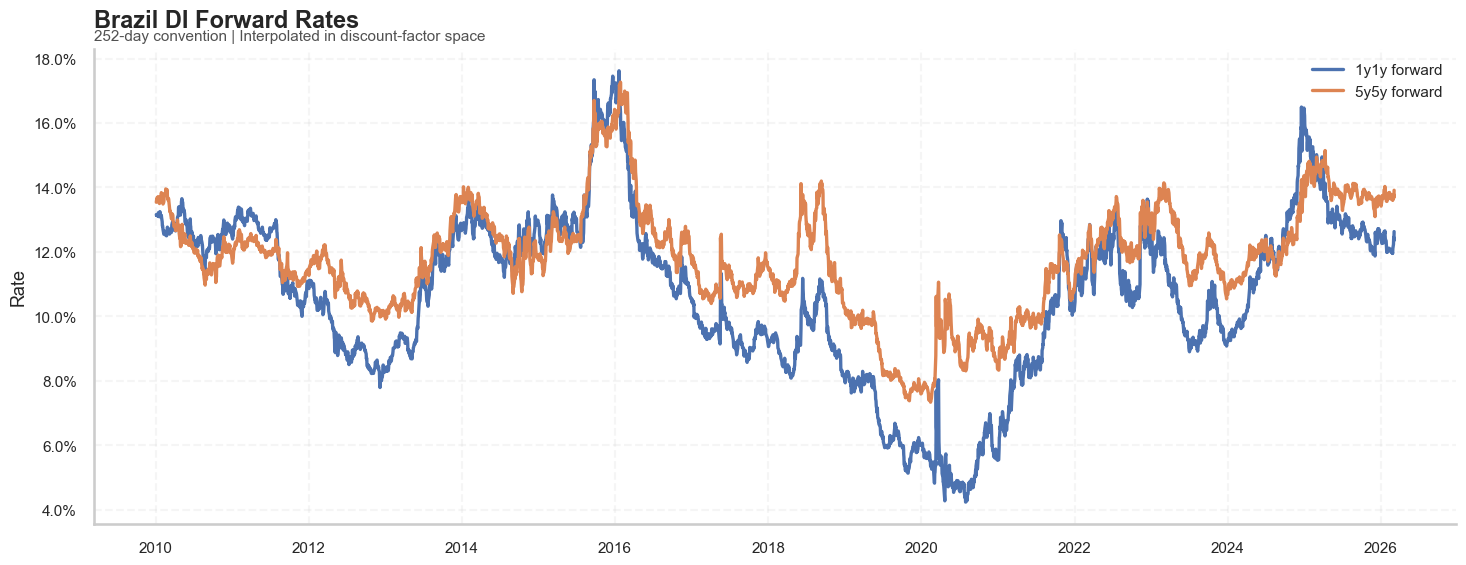

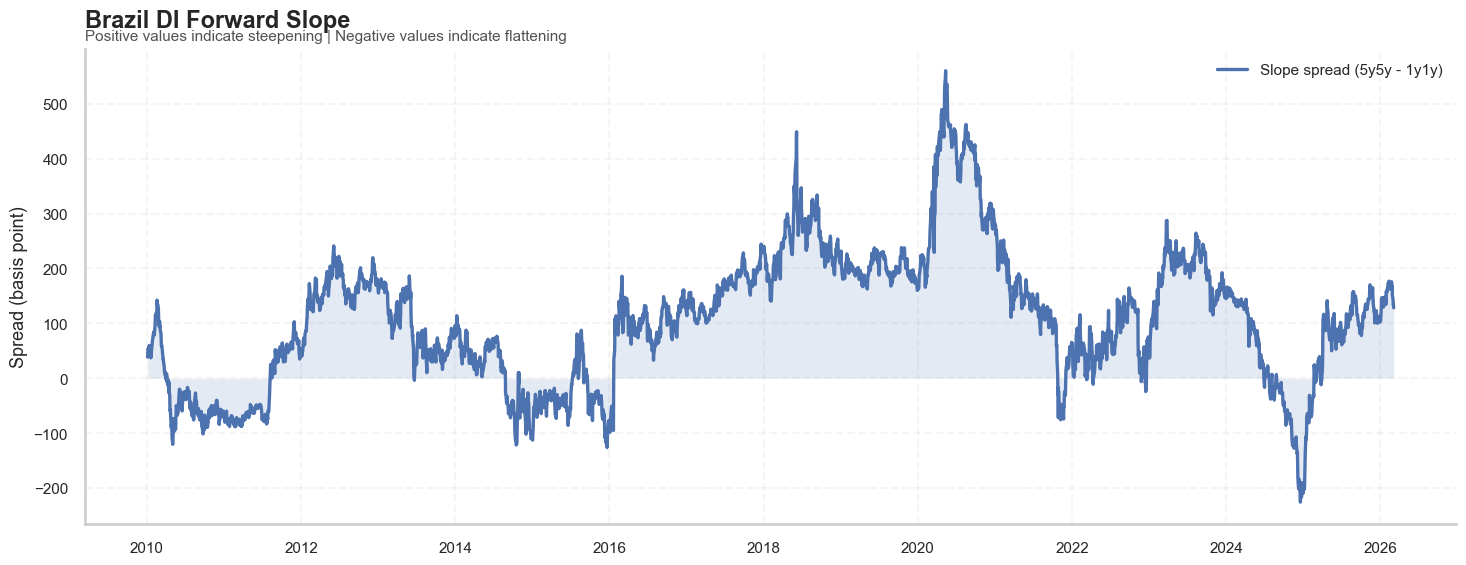

In [ ]:


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# ------------------------------------------------------------
# 0) Paths
# ------------------------------------------------------------
BASE_DIR = Path.cwd()
DATA_PROCESSED_DIR = BASE_DIR / "data_processed"
#FIG_DIR = BASE_DIR / "figures"
FIG_DIR = BASE_DIR / "figures" / "01_Build_DI"
#MACRO_FIG_DIR = FIG_DIR / "02_macro"
DATA_PROCESSED_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

CURVE_CSV = DATA_PROCESSED_DIR / "curve_forwards_252.csv"

# ------------------------------------------------------------
# 1) Load processed curve data
# ------------------------------------------------------------
curve_df = pd.read_csv(CURVE_CSV)
curve_df["date"] = pd.to_datetime(curve_df["date"])
curve_df = curve_df.sort_values("date").reset_index(drop=True)

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams.update({
    "figure.figsize": (15, 6),
    "axes.titlesize": 17,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.18,
    "grid.linestyle": "--",
    "lines.linewidth": 2.4,
    "savefig.dpi": 300,
})

def pct_formatter(x, pos):
    return f"{x:.1f}%"

def setup_time_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlabel("")
    sns.despine(ax=ax)

def add_subtitle(ax, subtitle: str):
    ax.text(
        0.0,
        1.02,
        subtitle,
        transform=ax.transAxes,
        fontsize=11,
        alpha=0.80
    )

# ------------------------------------------------------------
# 3) Figure 1 - 1y1y and 5y5y forwards
# ------------------------------------------------------------
fig, ax = plt.subplots()

ax.plot(
    curve_df["date"],
    curve_df["fwd_1y1y"],
    label="1y1y forward"
)

ax.plot(
    curve_df["date"],
    curve_df["fwd_5y5y"],
    label="5y5y forward"
)

ax.set_title("Brazil DI Forward Rates", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "252-day convention | Interpolated in discount-factor space")

ax.set_ylabel("Rate")
ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))

setup_time_axis(ax)

ax.legend(loc="upper right", frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_01_forwards_1y1y_5y5y_report.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_01_forwards_1y1y_5y5y_report.pdf", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 4) Figure 2 - Slope spread = 5y5y - 1y1y
# ------------------------------------------------------------
fig, ax = plt.subplots()

ax.plot(
    curve_df["date"],
    curve_df["spread_5y5y_minus_1y1y"]*100.0,
    label="Slope spread (5y5y - 1y1y)"
)

ax.fill_between(
    curve_df["date"],
    0,
    curve_df["spread_5y5y_minus_1y1y"]*100.0,
    alpha=0.15
)

#ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)

ax.set_title("Brazil DI Forward Slope", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Positive values indicate steepening | Negative values indicate flattening")

ax.set_ylabel("Spread (basis point)")
#ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))

setup_time_axis(ax)

ax.legend(loc="upper right", frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / "fig_02_slope_spread_5y5y_minus_1y1y_report.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_02_slope_spread_5y5y_minus_1y1y_report.pdf", bbox_inches="tight")
plt.show()

